In [1]:
import sys
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import geopandas as gpd
from shapely.geometry import mapping
from scipy.stats import spearmanr, pearsonr
import ts_onset_cess as ocd
import pandas as pd
from fapar_def import fapar_read

import warnings
warnings.filterwarnings('ignore')

In [2]:
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"

Y1=1990
Y2=2024

comps = 5

### Read in calculated recycling to add to the precipitation plots

In [3]:
#datao ="/Volumes/ESA_F4R/ed_prepare/2026_rho/mint_r02_it1000_tole3/bands_rho/" 
#datao = "/Volumes/ESA_F4R/ed_prepare/2026_rho/nudged_mint_r02_tol1e2_max500/"
datao = "/Volumes/ESA_F4R/ed_prepare/2026_rho/nudge_mint_r02_it1000_tole3/"
S_NAME = "S_SE" # S_SE or S_LSE 
L_NAME = "L_M" # L_M or L_HI
band = {'N':[5,12,10,31],'EQ':[-5,5,8,29],'S':[-15,-5,12,31]}
rho_xarr={}
for B in ['N','EQ','S']:
    print('running band:', B)
    #rho_xarr[B] = xr.open_mfdataset(datao+L_NAME+"_"+S_NAME+"_band_"+B+"_rot_rho_era5_*.nc",engine='netcdf4')
    rho_xarr[B] = xr.open_mfdataset(datao+L_NAME+"_"+S_NAME+"_band_"+B+"_rot_rho_era5_*.nc",engine='netcdf4')
    rho_xarr[B] = rho_xarr[B].sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))

running band: N
running band: EQ
running band: S


### Calculate roatational means for each month and band


In [4]:
#Monthly average plots - average rotation
rho_mon = {}
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for B in ['N','EQ','S']:
    rho_rot = rho_xarr[B]['rho'].mean('rot') 
    rho_mon[B] = rho_rot.groupby('time.month').mean(dim=('time','lat','lon'))
    rho_mon[B] = rho_mon[B].assign_coords(dayofyear=('month', [15,45,74,105,135,166,196,227,258,288,319,349]))
        

In [5]:
#fapar_in = fapar_read()
#fapar = xr.Dataset()
#fapar['N'] = fapar_in.sel(lat=slice(5,12),lon=slice(10,31)).mean(dim=('lat','lon'))
#fapar['EQ'] = fapar_in.sel(lat=slice(-5,5),lon=slice(8,29)).mean(dim=('lat','lon'))
#fapar['S'] = fapar_in.sel(lat=slice(-15,-5),lon=slice(12,31)).mean(dim=('lat','lon'))
#
#fapar.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/fapar_bands.nc')

In [6]:
fapar = xr.open_mfdataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/fapar_bands.nc')

In [7]:
print(fapar)

<xarray.Dataset> Size: 12kB
Dimensions:  (time: 364)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2014-01-10 2014-01-20 ... 2024-11-30
Data variables:
    N        (time) float64 3kB dask.array<chunksize=(364,), meta=np.ndarray>
    EQ       (time) float64 3kB dask.array<chunksize=(364,), meta=np.ndarray>
    S        (time) float64 3kB dask.array<chunksize=(364,), meta=np.ndarray>


### Read in TROPOMI (2018-2024)

In [8]:
#tropomi = xr.Dataset()
#tlistN = []
#tlistEQ = []
#tlistS = []
#qflag = 0.7
#for Y in range(2018,2025):
#    print('running year: ',str(Y))
#    tin = xr.open_dataset("/Volumes/ESA_F4R/tropomi/merged/TROPOMI_merged_"+str(Y)+".nc")
#    tlistN.append(tin.where((tin['qa_value']>qflag) & (tin.lat < 12.) & (tin.lat > 5.) & (tin.lon < 31.) & (tin.lon > 10.),drop=True).mean(dim=('ground_pixel','scanline'))['deltad'])
#    tlistEQ.append(tin.where((tin['qa_value']>qflag) & (tin.lat < 5.) & (tin.lat > -5.) & (tin.lon < 29.) & (tin.lon > 8.),drop=True).mean(dim=('ground_pixel','scanline'))['deltad'])
#    tlistS.append(tin.where((tin['qa_value']>qflag) & (tin.lat < -5.) & (tin.lat > -15.) & (tin.lon < 31.) & (tin.lon > 12.),drop=True).mean(dim=('ground_pixel','scanline'))['deltad'])
#tropomi['N'] = xr.concat(tlistN,dim='time')
#tropomi['EQ'] = xr.concat(tlistEQ,dim='time')
#tropomi['S'] = xr.concat(tlistS,dim='time')
#
#tropomi.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/tropomi_bands.nc')

In [9]:
tropomi = xr.open_mfdataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/tropomi_bands.nc')

### Read in precip 
- do this for whole available ts and then sub-select years in next step for analysis

In [10]:
#Y1=1981
#Y2=2025
#for Y in range(Y1,Y2+1):
#    prp = xr.open_mfdataset('/Volumes/blue_wd/chirps_daily/chirps-v2.0.'+str(Y)+'.days_p05.nc')['precip']
#    prp = prp.rename({'latitude':'lat','longitude':'lon'})
#    prpN = prp.sel(lat=slice(5,12),lon=slice(10,31),drop=True).load()
#    prpEQ = prp.sel(lat=slice(-5,5),lon=slice(8,29),drop=True).load()
#    prpS = prp.sel(lat=slice(-15,-5),lon=slice(12,31),drop=True).load()
#    if Y==Y1:
#        prpaN = prpN
#        prpaEQ = prpEQ
#        prpaS = prpS
#    else:
#        prpaN = xr.concat([prpaN,prpN],dim='time')
#        prpaEQ = xr.concat([prpaEQ,prpEQ],dim='time')
#        prpaS = xr.concat([prpaS,prpS],dim='time')
#        prpN.close()
#        prpEQ.close()
#        prpS.close()
#prpaN.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_N.nc',engine='h5netcdf')
#prpaN.close()
#prpaEQ.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_EQ.nc',engine='h5netcdf')
#prpaEQ.close()
#prpaS.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_S.nc',engine='h5netcdf')
#prpaS.close()
#        

In [11]:
pr = {}
prp = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_N.nc')['precip']
pr['N'] = prp.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))
prp = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_EQ.nc')['precip']
pr['EQ'] = prp.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))
prp = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_S.nc')['precip']
pr['S'] = prp.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))


## Equatorial Band

- Checking to see if wet and dry seasons have consistently different onset and cessation dates

- Calculate wet and dry season composites for season 1 and season 2

- Calculate the onset and cessation of full climatology for all seasons

- Calculate onset and cessation of wet and dry composite seasons

- Calculate mean of onset and cessation composites

- Plot everything

In [12]:
#Equatorial Band

P = pr['EQ'] 
FP = fapar['EQ']
FP = FP.groupby('time.dayofyear').mean('time')

TP = tropomi['EQ']
TP = TP.groupby('time.dayofyear').mean('time')

#Composite season years - S1
PA = P.mean(dim=('lat','lon')).where(P['time.dayofyear']<200).groupby('time.year').mean('time')
sort_index = PA.sortby(PA)
dryS1 = sort_index[0:comps]['year']
wetS1 = sort_index[-comps:]['year']
print('Dry years S1',dryS1['year'].values)
print('Wet years S1',wetS1['year'].values)
PW1 = P.sel(time=P['time.year'].isin(wetS1['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
PD1 = P.sel(time=P['time.year'].isin(dryS1['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
#Composite season years - S2
PA = P.mean(dim=('lat','lon')).where(P['time.dayofyear']>200).groupby('time.year').mean('time')
sort_index = PA.sortby(PA)
dryS2 = sort_index[0:comps]['year']
wetS2 = sort_index[-comps:]['year']
print('Dry years S2',dryS2['year'].values)
print('Wet years S2',wetS2['year'].values)
PW2 = P.sel(time=P['time.year'].isin(wetS2['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
PD2 = P.sel(time=P['time.year'].isin(dryS2['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
print('----------------------------------------------------')


#Season timing
print(P.mean(dim=("lat","lon")))
power_ratio,on1,ce1,on2,ce2,on3,ce3,on1_years,ce1_years,on2_years,ce2_years,on3_years,ce3_years = ocd.xarray_on_cess_point(P.mean(dim=("lat","lon")))

mean_onset_1 = on1_years.mean('year').values 
mean_cess_1 = ce1_years.mean('year').values 
mean_onset_2 = on2_years.mean('year').values 
mean_cess_2 = ce2_years.mean('year').values
print('All years mean onset 1', mean_onset_1, 'All years mean cessation 1', mean_cess_1)
print('All years mean onset 2', mean_onset_2, 'All years mean cessation 2', mean_cess_2)
print('----------------------------------------------------')

#Onset and cessation of wet and dry composite years

print('Wet years onset 1: ',on1_years.sel(year=on1_years['year'].isin(wetS1['year'].values)).mean('year').values ,
      'Dry years onset 1: ',on1_years.sel(year=on1_years['year'].isin(dryS1['year'].values)).mean('year').values)
print('Wet years cessation 1: ',ce1_years.sel(year=ce1_years['year'].isin(wetS1['year'].values)).mean('year').values ,
      'Dry years cessation1: ',ce1_years.sel(year=ce1_years['year'].isin(dryS1['year'].values)).mean('year').values)

print('Wet years onset 2: ',on2_years.sel(year=on2_years['year'].isin(wetS2['year'].values)).mean('year').values ,
      'Dry years onset 2: ',on2_years.sel(year=on2_years['year'].isin(dryS2['year'].values)).mean('year').values)
print('Wet years cessation 2: ',ce2_years.sel(year=ce2_years['year'].isin(wetS2['year'].values)).mean('year').values ,
      'Dry years cessation2: ',ce2_years.sel(year=ce2_years['year'].isin(dryS2['year'].values)).mean('year').values)
print('----------------------------------------------------')

#Onset and cessation of early and late composite years

sort_index_onset = on1_years.sortby(on1_years)
early_onset1 = sort_index_onset[0:comps]
late_onset1 = sort_index_onset[-comps:]
early_onset_precip = PA.where(PA['year'].isin(early_onset1['year']),drop=True)
late_onset_precip = PA.where(PA['year'].isin(late_onset1['year']),drop=True)
print('Mean early onset comp S1 ',early_onset1.mean('year').values, 'Years: ',early_onset1['year'].values, 'Early onset comp S1 ',early_onset1.values)
print('Mean late onset comp S1 ',late_onset1.mean('year').values, 'Years: ',late_onset1['year'].values, 'Late onset comp S1 ',late_onset1.values)

sort_index_cess = ce1_years.sortby(ce1_years)
early_cess1 = sort_index_cess[0:comps]
late_cess1 = sort_index_cess[-comps:]
early_cess_precip = PA.where(PA['year'].isin(early_cess1['year']),drop=True)
late_cess_precip = PA.where(PA['year'].isin(late_cess1['year']),drop=True)
print('Mean early cess comp S1 ',early_cess1.mean('year').values, 'Years: ',early_cess1['year'].values, 'Early cess comp S1 ',early_cess1.values)
print('Mean late cess comp S1 ',late_cess1.mean('year').values, 'Years: ',late_cess1['year'].values, 'Late cess comp S1 ',late_cess1.values)
print('----------------------------------------------------')

sort_index_onset = on2_years.sortby(on2_years)
early_onset2 = sort_index_onset[0:comps]
late_onset2 = sort_index_onset[-comps:]
early_onset_precip = PA.where(PA['year'].isin(early_onset2['year']),drop=True)
late_onset_precip = PA.where(PA['year'].isin(late_onset2['year']),drop=True)
print('Mean early onset comp S2 ',early_onset2.mean('year').values, 'Years: ',early_onset2['year'].values, 'Early onset comp S2 ',early_onset2.values)
print('Mean late onset comp S2 ',late_onset2.mean('year').values, 'Years: ',late_onset2['year'].values, 'Late onset comp S2 ',late_onset2.values)

sort_index_cess = ce2_years.sortby(ce2_years)
early_cess2 = sort_index_cess[0:comps]
late_cess2 = sort_index_cess[-comps:]
early_cess_precip = PA.where(PA['year'].isin(early_cess2['year']),drop=True)
late_cess_precip = PA.where(PA['year'].isin(late_cess2['year']),drop=True)
print('Mean early cess comp S2 ',early_cess2.mean('year').values, 'Years: ',early_cess2['year'].values, 'Early cess comp S2 ',early_cess2.values)
print('Mean late cess comp S2 ',late_cess2.mean('year').values, 'Years: ',late_cess2['year'].values, 'Late cess comp S2 ',late_cess2.values)
print('----------------------------------------------------')


Dry years S1 [2024 2004 2015 1998 1994]
Wet years S1 [1997 1996 2009 1991 1999]
Dry years S2 [2015 1991 2024 1996 2014]
Wet years S2 [1997 2000 1990 2018 1999]
----------------------------------------------------
<xarray.DataArray 'precip' (time: 12784)> Size: 51kB
array([3.8278155, 2.9234471, 6.038126 , ..., 3.4283516, 4.243788 ,
       2.3774192], shape=(12784,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 102kB 1990-01-01 1990-01-02 ... 2024-12-31
Attributes:
    units:               mm/day
    standard_name:       convective precipitation rate
    long_name:           Climate Hazards group InfraRed Precipitation with St...
    time_step:           day
    geostatial_lat_min:  -50.0
    geostatial_lat_max:  50.0
    geostatial_lon_min:  -180.0
    geostatial_lon_max:  180.0
All years mean onset 1 64.0909090909091 All years mean cessation 1 142.9090909090909
All years mean onset 2 247.15151515151516 All years mean cessation 2 340.72727272727275
--------------------

<Figure size 640x480 with 0 Axes>

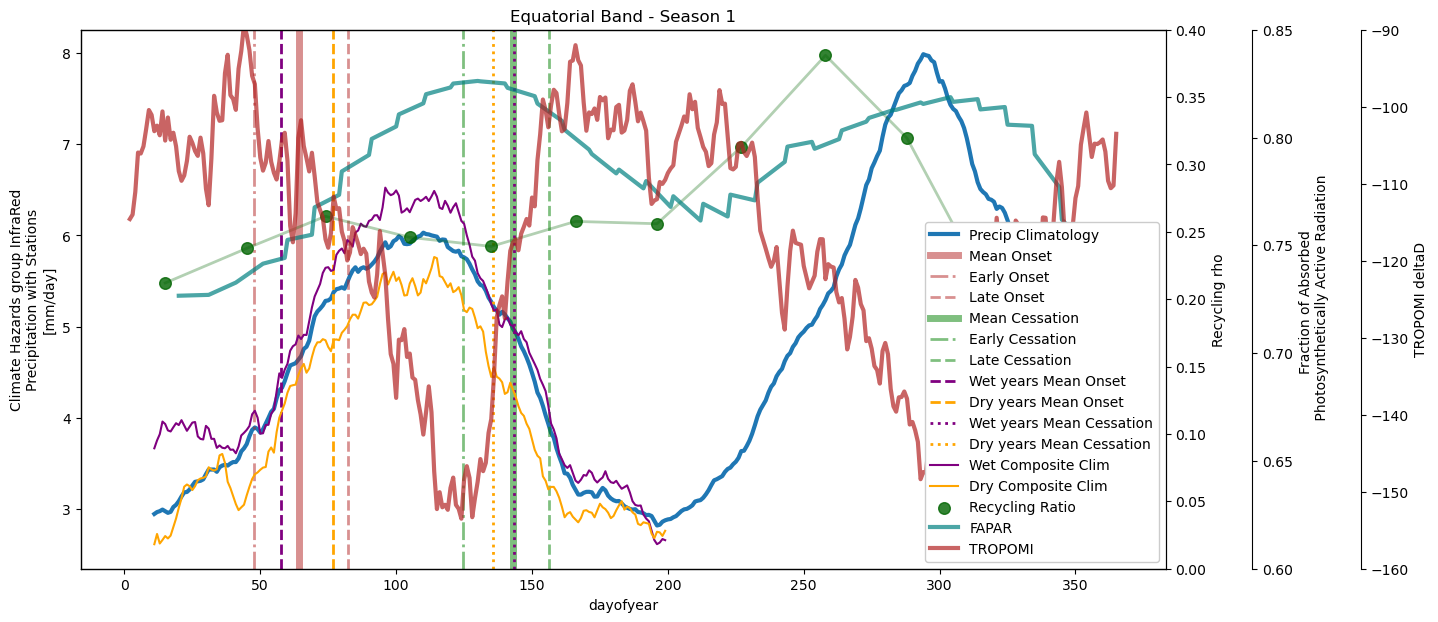

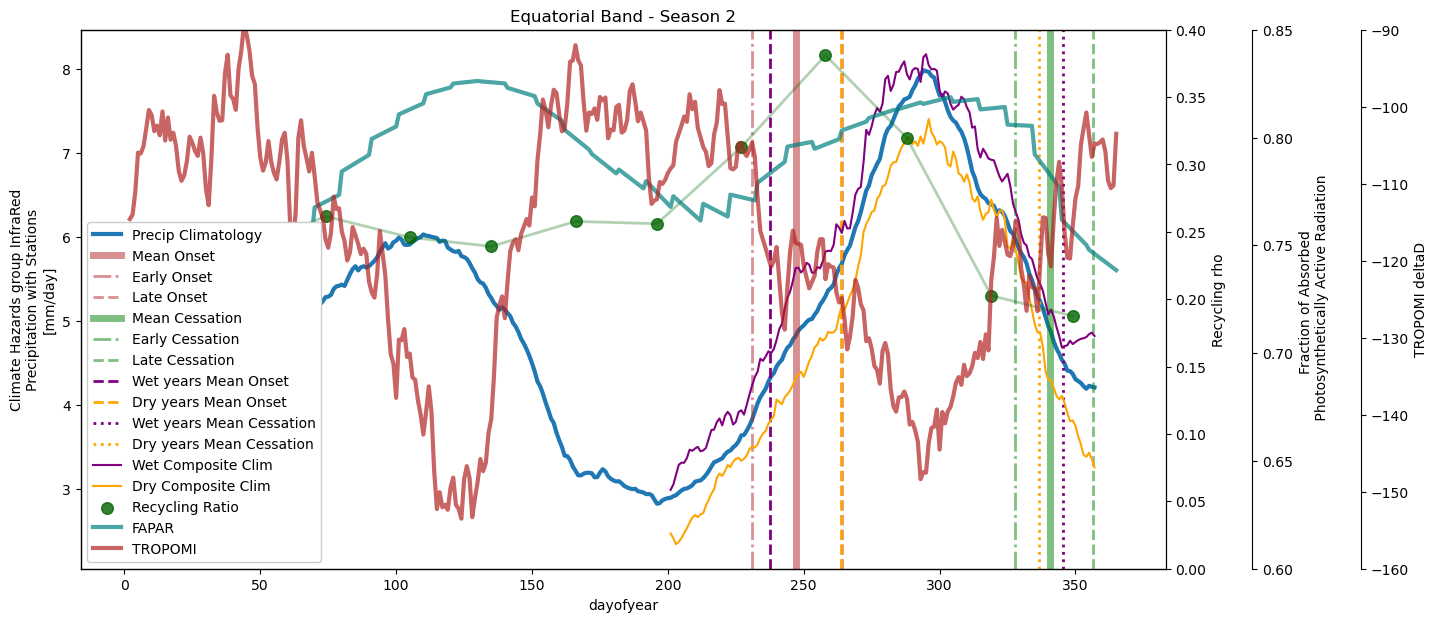

In [13]:
#Plot everything - SEASON 1

fig,ax = plt.subplots(figsize=(14, 7))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

plt.axvline(x=on1_years.mean('year').values, color='firebrick', linestyle='-', linewidth=5,alpha=0.5,label='Mean Onset')
plt.axvline(x=early_onset1.mean('year'), color='firebrick', linestyle='-.', linewidth=2,alpha=0.5,label='Early Onset')
plt.axvline(x=late_onset1.mean('year'), color='firebrick', linestyle='--', linewidth=2,alpha=0.5,label='Late Onset')

plt.axvline(x=ce1_years.mean('year').values, color='green', linestyle='-', linewidth=5,alpha=0.5,label='Mean Cessation')
plt.axvline(x=early_cess1.mean('year'), color='green', linestyle='-.', linewidth=2,alpha=0.5,label='Early Cessation')
plt.axvline(x=late_cess1.mean('year'), color='green', linestyle='--', linewidth=2,alpha=0.5,label='Late Cessation')

plt.axvline(x=on1_years.sel(year=on1_years['year'].isin(wetS1['year'].values)).mean('year').values, color='purple', linestyle='--', linewidth=2,alpha=1,label='Wet years Mean Onset')
plt.axvline(x=on1_years.sel(year=on1_years['year'].isin(dryS1['year'].values)).mean('year').values, color='orange', linestyle='--', linewidth=2,alpha=1,label='Dry years Mean Onset')
plt.axvline(x=ce1_years.sel(year=ce1_years['year'].isin(wetS1['year'].values)).mean('year').values, color='purple', linestyle='dotted', linewidth=2,alpha=1,label='Wet years Mean Cessation')
plt.axvline(x=ce1_years.sel(year=ce1_years['year'].isin(dryS1['year'].values)).mean('year').values, color='orange', linestyle='dotted', linewidth=2,alpha=1,label='Dry years Mean Cessation')

PonE = P.mean(dim=('lat','lon')).sel(time=P['time.year'].isin(early_onset1['year'].values)).groupby('time.dayofyear').mean('time').rolling(dayofyear=30, center=True).mean('dayofyear')
PonE = PonE.where(PonE['dayofyear']<200)
PonL = P.mean(dim=('lat','lon')).sel(time=P['time.year'].isin(late_onset1['year'].values)).groupby('time.dayofyear').mean('time').rolling(dayofyear=30, center=True).mean('dayofyear')
PonL = PonL.where(PonL['dayofyear']<200)

PceE = P.mean(dim=('lat','lon')).sel(time=P['time.year'].isin(early_cess1['year'].values)).groupby('time.dayofyear').mean('time').rolling(dayofyear=30, center=True).mean('dayofyear')
PceE = PceE.where(PceE['dayofyear']<200)
PceL = P.mean(dim=('lat','lon')).sel(time=P['time.year'].isin(late_cess1['year'].values)).groupby('time.dayofyear').mean('time').rolling(dayofyear=30, center=True).mean('dayofyear')
PceL = PceL.where(PceL['dayofyear']<200)

#plt.fill_between(PonL[0:365].dayofyear,PonE[0:365],PonL[0:365], color='red',alpha=0.3,label="Early vs Late Onset")
#plt.fill_between(PceL[0:365].dayofyear,PceE[0:365],PceL[0:365],color='green',alpha=0.3,label="Early vs Late Cess")
#PonE.plot(linestyle='--',color='red',alpha=1,label="Early Onset Clim")
#PceL.plot(linestyle='--',color='green',alpha=1,label="Late Cessation Clim")

PW1R = PW1.rolling(dayofyear=20, center=True).mean('dayofyear').where(PW1['dayofyear']<200)
PD1R = PD1.rolling(dayofyear=20, center=True).mean('dayofyear').where(PW1['dayofyear']<200)
PW1R.plot(linestyle='-',color='purple',alpha=1,label="Wet Composite Clim")
PD1R.plot(linestyle='-',color='orange',alpha=1,label="Dry Composite Clim")

ax2 = ax.twinx()
ax3 = ax.twinx()
ax4 = ax.twinx()
ax3.spines.right.set_position(("axes", 1.08))
ax4.spines.right.set_position(("axes", 1.18))

ax2.plot(rho_mon['EQ']['dayofyear'],rho_mon['EQ'],linestyle='-',linewidth=2,color='darkgreen',alpha=0.3)
ax2.scatter(rho_mon['EQ']['dayofyear'],rho_mon['EQ'],s=70,color='darkgreen',label='Recycling Ratio',alpha=0.8)
ax2.set(ylim=(0,0.4), ylabel='Recycling rho')

FPR = FP.rolling(dayofyear=3, center=True).mean('dayofyear')
ax3.plot(FPR['dayofyear'],FPR,linestyle='-',linewidth=3,color='teal',alpha=0.7,label='FAPAR')
ax3.set(ylim=(0.6,0.85),ylabel='Fraction of Absorbed \n Photosynthetically Active Radiation')

TPR = TP.rolling(dayofyear=3, center=True).mean('dayofyear')
ax4.plot(TPR['dayofyear'],TPR,linestyle='-',linewidth=3,color='firebrick',alpha=0.7,label='TROPOMI')
ax4.set(ylim=(-160,-90),ylabel='TROPOMI deltaD')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2 + lines3 + lines4, labels + labels2 + labels3 + labels4, framealpha=1.0, loc='lower right')

plt.title('Equatorial Band - Season 1')
plt.savefig(datap+'EQ_S1_timing_pres.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()
plt.close()


#Plot everything - SEASON 2

fig,ax = plt.subplots(figsize=(14, 7))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

plt.axvline(x=on2_years.mean('year').values, color='firebrick', linestyle='-', linewidth=5,alpha=0.5,label='Mean Onset')
plt.axvline(x=early_onset2.mean('year'), color='firebrick', linestyle='-.', linewidth=2,alpha=0.5,label='Early Onset')
plt.axvline(x=late_onset2.mean('year'), color='firebrick', linestyle='--', linewidth=2,alpha=0.5,label='Late Onset')

plt.axvline(x=ce2_years.mean('year').values, color='green', linestyle='-', linewidth=5,alpha=0.5,label='Mean Cessation')
plt.axvline(x=early_cess2.mean('year'), color='green', linestyle='-.', linewidth=2,alpha=0.5,label='Early Cessation')
plt.axvline(x=late_cess2.mean('year'), color='green', linestyle='--', linewidth=2,alpha=0.5,label='Late Cessation')

plt.axvline(x=on2_years.sel(year=on2_years['year'].isin(wetS2['year'].values)).mean('year').values, color='purple', linestyle='--', linewidth=2,alpha=1,label='Wet years Mean Onset')
plt.axvline(x=on2_years.sel(year=on2_years['year'].isin(dryS2['year'].values)).mean('year').values, color='orange', linestyle='--', linewidth=2,alpha=1,label='Dry years Mean Onset')
plt.axvline(x=ce2_years.sel(year=ce2_years['year'].isin(wetS2['year'].values)).mean('year').values, color='purple', linestyle='dotted', linewidth=2,alpha=1,label='Wet years Mean Cessation')
plt.axvline(x=ce2_years.sel(year=ce2_years['year'].isin(dryS2['year'].values)).mean('year').values, color='orange', linestyle='dotted', linewidth=2,alpha=1,label='Dry years Mean Cessation')

PonE = P.mean(dim=('lat','lon')).sel(time=P['time.year'].isin(early_onset2['year'].values)).groupby('time.dayofyear').mean('time').rolling(dayofyear=30, center=True).mean('dayofyear')
PonE = PonE.where(PonE['dayofyear']>200)
PonL = P.mean(dim=('lat','lon')).sel(time=P['time.year'].isin(late_onset2['year'].values)).groupby('time.dayofyear').mean('time').rolling(dayofyear=30, center=True).mean('dayofyear')
PonL = PonL.where(PonL['dayofyear']>200)

PceE = P.mean(dim=('lat','lon')).sel(time=P['time.year'].isin(early_cess2['year'].values)).groupby('time.dayofyear').mean('time').rolling(dayofyear=30, center=True).mean('dayofyear')
PceE = PceE.where(PceE['dayofyear']>200)
PceL = P.mean(dim=('lat','lon')).sel(time=P['time.year'].isin(late_cess2['year'].values)).groupby('time.dayofyear').mean('time').rolling(dayofyear=30, center=True).mean('dayofyear')
PceL = PceL.where(PceL['dayofyear']>200)

#plt.fill_between(PonL[0:365].dayofyear,PonE[0:365],PonL[0:365], color='red',alpha=0.3,label="Early vs Late Onset")
#plt.fill_between(PceL[0:365].dayofyear,PceE[0:365],PceL[0:365],color='green',alpha=0.3,label="Early vs Late Cess")
#PonE.plot(linestyle='--',color='red',alpha=1,label="Early Onset Clim")
#PceL.plot(linestyle='--',color='green',alpha=1,label="Late Cessation Clim")

PW2R = PW2.rolling(dayofyear=20, center=True).mean('dayofyear').where(PW2['dayofyear']>200)
PD2R = PD2.rolling(dayofyear=20, center=True).mean('dayofyear').where(PW2['dayofyear']>200)
PW2R.plot(linestyle='-',color='purple',alpha=1,label="Wet Composite Clim")
PD2R.plot(linestyle='-',color='orange',alpha=1,label="Dry Composite Clim")

ax2 = ax.twinx()
ax3 = ax.twinx()
ax4 = ax.twinx()
ax3.spines.right.set_position(("axes", 1.08))
ax4.spines.right.set_position(("axes", 1.18))

ax2.plot(rho_mon['EQ']['dayofyear'],rho_mon['EQ'],linestyle='-',linewidth=2,color='darkgreen',alpha=0.3)
ax2.scatter(rho_mon['EQ']['dayofyear'],rho_mon['EQ'],s=70,color='darkgreen',label='Recycling Ratio',alpha=0.8)
ax2.set(ylim=(0,0.4),ylabel='Recycling rho')

FPR = FP.rolling(dayofyear=3, center=True).mean('dayofyear')
ax3.plot(FPR['dayofyear'],FPR,linestyle='-',linewidth=3,color='teal',alpha=0.7,label='FAPAR')
ax3.set(ylim=(0.6,0.85),ylabel='Fraction of Absorbed \n Photosynthetically Active Radiation')

TPR = TP.rolling(dayofyear=3, center=True).mean('dayofyear')
ax4.plot(TPR['dayofyear'],TPR,linestyle='-',linewidth=3,color='firebrick',alpha=0.7,label='TROPOMI')
ax4.set(ylim=(-160,-90),ylabel='TROPOMI deltaD')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2 + lines3 + lines4, labels + labels2 + labels3 + labels4, framealpha=1.0, loc='lower left')

plt.title('Equatorial Band - Season 2')
plt.savefig(datap+'EQ_S2_timing_pres.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()
plt.close()


In [14]:
#North Band

P = pr['N'] 
FP = fapar['N']
FP = FP.groupby('time.dayofyear').mean('time')

TP = tropomi['N']
TP = TP.groupby('time.dayofyear').mean('time')

#Composite season years - S1
PA = P.mean(dim=('lat','lon')).groupby('time.year').mean('time')
sort_index = PA.sortby(PA)
dryS1 = sort_index[0:comps]['year']
wetS1 = sort_index[-comps:]['year']
print('Dry years S1',dryS1['year'].values)
print('Wet years S1',wetS1['year'].values)
PW1 = P.sel(time=P['time.year'].isin(wetS1['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
PD1 = P.sel(time=P['time.year'].isin(dryS1['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
print('----------------------------------------------------')


#Season timing
power_ratio,on1,ce1,on2,ce2,on3,ce3,on1_years,ce1_years,on2_years,ce2_years,on3_years,ce3_years = ocd.xarray_on_cess_point(P.mean(dim=("lat","lon")))

mean_onset_1 = on1_years.mean('year').values 
mean_cess_1 = ce1_years.mean('year').values 
mean_onset_2 = on2_years.mean('year').values 
mean_cess_2 = ce2_years.mean('year').values
print('All years mean onset 1', mean_onset_1, 'All years mean cessation 1', mean_cess_1)
print('All years mean onset 2', mean_onset_2, 'All years mean cessation 2', mean_cess_2)
print('----------------------------------------------------')

#Onset and cessation of wet and dry composite years

print('Wet years onset 1: ',on1_years.sel(year=on1_years['year'].isin(wetS1['year'].values)).mean('year').values ,
      'Dry years onset 1: ',on1_years.sel(year=on1_years['year'].isin(dryS1['year'].values)).mean('year').values)
print('Wet years cessation 1: ',ce1_years.sel(year=ce1_years['year'].isin(wetS1['year'].values)).mean('year').values ,
      'Dry years cessation1: ',ce1_years.sel(year=ce1_years['year'].isin(dryS1['year'].values)).mean('year').values)
print('----------------------------------------------------')

#Onset and cessation of early and late composite years

sort_index_onset = on1_years.sortby(on1_years)
early_onset1 = sort_index_onset[0:comps]
late_onset1 = sort_index_onset[-comps:]
early_onset_precip = PA.where(PA['year'].isin(early_onset1['year']),drop=True)
late_onset_precip = PA.where(PA['year'].isin(late_onset1['year']),drop=True)
print('Mean early onset comp S1 ',early_onset1.mean('year').values, 'Years: ',early_onset1['year'].values, 'Early onset comp S1 ',early_onset1.values)
print('Mean late onset comp S1 ',late_onset1.mean('year').values, 'Years: ',late_onset1['year'].values, 'Late onset comp S1 ',late_onset1.values)

sort_index_cess = ce1_years.sortby(ce1_years)
early_cess1 = sort_index_cess[0:comps]
late_cess1 = sort_index_cess[-comps:]
early_cess_precip = PA.where(PA['year'].isin(early_cess1['year']),drop=True)
late_cess_precip = PA.where(PA['year'].isin(late_cess1['year']),drop=True)
print('Mean early cess comp S1 ',early_cess1.mean('year').values, 'Years: ',early_cess1['year'].values, 'Early cess comp S1 ',early_cess1.values)
print('Mean late cess comp S1 ',late_cess1.mean('year').values, 'Years: ',late_cess1['year'].values, 'Late cess comp S1 ',late_cess1.values)
print('----------------------------------------------------')


Dry years S1 [2004 2008 2009 1990 2007]
Wet years S1 [1997 2010 1999 2012 2019]
----------------------------------------------------
All years mean onset 1 124.36363636363636 All years mean cessation 1 297.90909090909093
All years mean onset 2 nan All years mean cessation 2 nan
----------------------------------------------------
Wet years onset 1:  121.0 Dry years onset 1:  130.25
Wet years cessation 1:  302.4 Dry years cessation1:  299.25
----------------------------------------------------
Mean early onset comp S1  113.8 Years:  [2005 1993 1997 2007 1998] Early onset comp S1  [111. 112. 115. 115. 116.]
Mean late onset comp S1  144.2 Years:  [2003 2020 2011 2002 2009] Late onset comp S1  [137. 140. 142. 149. 153.]
Mean early cess comp S1  287.6 Years:  [2017 2018 2008 2001 2013] Early cess comp S1  [285. 287. 288. 289. 289.]
Mean late cess comp S1  305.6 Years:  [2015 2023 1994 2009 1997] Late cess comp S1  [304. 305. 306. 306. 307.]
--------------------------------------------------

<Figure size 640x480 with 0 Axes>

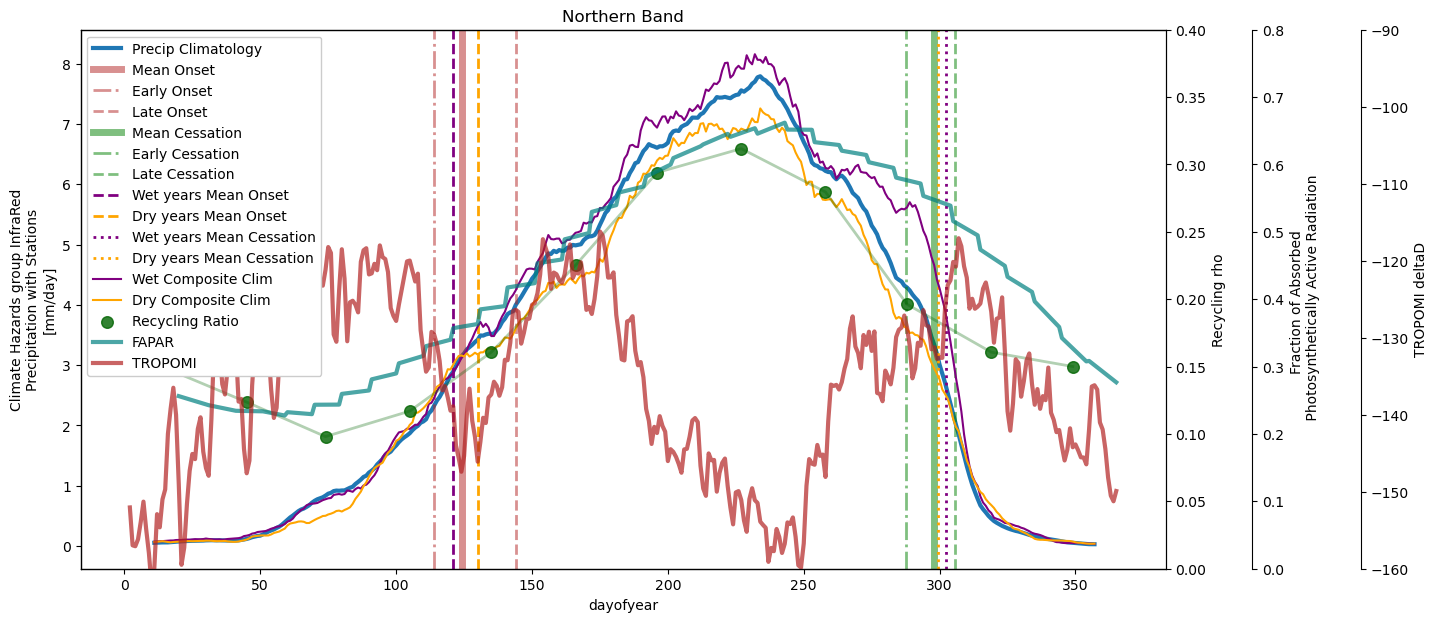

<Figure size 640x480 with 0 Axes>

In [15]:
#Plot everything - SEASON 1

fig,ax = plt.subplots(figsize=(14, 7))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

plt.axvline(x=on1_years.mean('year').values, color='firebrick', linestyle='-', linewidth=5,alpha=0.5,label='Mean Onset')
plt.axvline(x=early_onset1.mean('year'), color='firebrick', linestyle='-.', linewidth=2,alpha=0.5,label='Early Onset')
plt.axvline(x=late_onset1.mean('year'), color='firebrick', linestyle='--', linewidth=2,alpha=0.5,label='Late Onset')

plt.axvline(x=ce1_years.mean('year').values, color='green', linestyle='-', linewidth=5,alpha=0.5,label='Mean Cessation')
plt.axvline(x=early_cess1.mean('year'), color='green', linestyle='-.', linewidth=2,alpha=0.5,label='Early Cessation')
plt.axvline(x=late_cess1.mean('year'), color='green', linestyle='--', linewidth=2,alpha=0.5,label='Late Cessation')

plt.axvline(x=on1_years.sel(year=on1_years['year'].isin(wetS1['year'].values)).mean('year').values, color='purple', linestyle='--', linewidth=2,alpha=1,label='Wet years Mean Onset')
plt.axvline(x=on1_years.sel(year=on1_years['year'].isin(dryS1['year'].values)).mean('year').values, color='orange', linestyle='--', linewidth=2,alpha=1,label='Dry years Mean Onset')
plt.axvline(x=ce1_years.sel(year=ce1_years['year'].isin(wetS1['year'].values)).mean('year').values, color='purple', linestyle='dotted', linewidth=2,alpha=1,label='Wet years Mean Cessation')
plt.axvline(x=ce1_years.sel(year=ce1_years['year'].isin(dryS1['year'].values)).mean('year').values, color='orange', linestyle='dotted', linewidth=2,alpha=1,label='Dry years Mean Cessation')

PonE = P.mean(dim=('lat','lon')).sel(time=P['time.year'].isin(early_onset1['year'].values)).groupby('time.dayofyear').mean('time').rolling(dayofyear=30, center=True).mean('dayofyear')
PonL = P.mean(dim=('lat','lon')).sel(time=P['time.year'].isin(late_onset1['year'].values)).groupby('time.dayofyear').mean('time').rolling(dayofyear=30, center=True).mean('dayofyear')

PceE = P.mean(dim=('lat','lon')).sel(time=P['time.year'].isin(early_cess1['year'].values)).groupby('time.dayofyear').mean('time').rolling(dayofyear=30, center=True).mean('dayofyear')
PceL = P.mean(dim=('lat','lon')).sel(time=P['time.year'].isin(late_cess1['year'].values)).groupby('time.dayofyear').mean('time').rolling(dayofyear=30, center=True).mean('dayofyear')

#plt.fill_between(PonE[0:365].dayofyear,PonE[0:365],PonL[0:365], color='red',alpha=0.3,label="Early vs Late Onset")
#plt.fill_between(PceL[0:365].dayofyear,PceE[0:365],PceL[0:365],color='green',alpha=0.3,label="Early vs Late Cess")
#PonE.plot(linestyle='--',color='red',alpha=1,label="Early Onset Clim")
#PceL.plot(linestyle='--',color='green',alpha=1,label="Late Cessation Clim")

PW1R = PW1.rolling(dayofyear=20, center=True).mean('dayofyear')
PD1R = PD1.rolling(dayofyear=20, center=True).mean('dayofyear')
PW1R.plot(linestyle='-',color='purple',alpha=1,label="Wet Composite Clim")
PD1R.plot(linestyle='-',color='orange',alpha=1,label="Dry Composite Clim")

ax2 = ax.twinx()
ax3 = ax.twinx()
ax4 = ax.twinx()
ax3.spines.right.set_position(("axes", 1.08))
ax4.spines.right.set_position(("axes", 1.18))

ax2.plot(rho_mon['N']['dayofyear'],rho_mon['N'],linestyle='-',linewidth=2,color='darkgreen',alpha=0.3)
ax2.scatter(rho_mon['N']['dayofyear'],rho_mon['N'],s=70,color='darkgreen',label='Recycling Ratio',alpha=0.8)
ax2.set(ylim=(0,0.4),ylabel='Recycling rho')

FPR = FP.rolling(dayofyear=3, center=True).mean('dayofyear')
ax3.plot(FPR['dayofyear'],FPR,linestyle='-',linewidth=3,color='teal',alpha=0.7,label='FAPAR')
ax3.set(ylim=(0.0,0.8),ylabel='Fraction of Absorbed \n Photosynthetically Active Radiation')

TPR = TP.rolling(dayofyear=3, center=True).mean('dayofyear')
ax4.plot(TPR['dayofyear'],TPR,linestyle='-',linewidth=3,color='firebrick',alpha=0.7,label='TROPOMI')
ax4.set(ylim=(-160,-90),ylabel='TROPOMI deltaD')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2 + lines3 + lines4, labels + labels2 + labels3 + labels4, framealpha=1.0, loc='upper left')

plt.title('Northern Band')
plt.savefig(datap+'N_S1_timing_pres.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()

In [16]:
#Southern Band

P = pr['S'] 
FP = fapar['S']
FP = FP.groupby('time.dayofyear').mean('time')

TP = tropomi['S']
TP = TP.groupby('time.dayofyear').mean('time')

#Composite season years - S1
PA = P.mean(dim=('lat','lon')).groupby('time.year').mean('time')
sort_index = PA.sortby(PA)
dryS1 = sort_index[0:comps]['year']
wetS1 = sort_index[-comps:]['year']
print('Dry years S1',dryS1['year'].values)
print('Wet years S1',wetS1['year'].values)
PW1 = P.sel(time=P['time.year'].isin(wetS1['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
PD1 = P.sel(time=P['time.year'].isin(dryS1['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
print('----------------------------------------------------')


#Season timing
power_ratio,on1,ce1,on2,ce2,on3,ce3,on1_years,ce1_years,on2_years,ce2_years,on3_years,ce3_years = ocd.xarray_on_cess_point(P.mean(dim=("lat","lon")))

mean_onset_1 = on1_years.mean('year').values 
mean_cess_1 = ce1_years.mean('year').values 
mean_onset_2 = on2_years.mean('year').values 
mean_cess_2 = ce2_years.mean('year').values
print('All years mean onset 1', mean_onset_1, 'All years mean cessation 1', mean_cess_1)
print('All years mean onset 2', mean_onset_2, 'All years mean cessation 2', mean_cess_2)
print('----------------------------------------------------')

#Onset and cessation of wet and dry composite years

print('Wet years onset 1: ',on1_years.sel(year=on1_years['year'].isin(wetS1['year'].values)).mean('year').values ,
      'Dry years onset 1: ',on1_years.sel(year=on1_years['year'].isin(dryS1['year'].values)).mean('year').values)
print('Wet years cessation 1: ',ce1_years.sel(year=ce1_years['year'].isin(wetS1['year'].values)).mean('year').values ,
      'Dry years cessation1: ',ce1_years.sel(year=ce1_years['year'].isin(dryS1['year'].values)).mean('year').values)
print('----------------------------------------------------')

#Onset and cessation of early and late composite years

sort_index_onset = on1_years.sortby(on1_years)
early_onset1 = sort_index_onset[0:comps]
late_onset1 = sort_index_onset[-comps:]
early_onset_precip = PA.where(PA['year'].isin(early_onset1['year']),drop=True)
late_onset_precip = PA.where(PA['year'].isin(late_onset1['year']),drop=True)
print('Mean early onset comp S1 ',early_onset1.mean('year').values, 'Years: ',early_onset1['year'].values, 'Early onset comp S1 ',early_onset1.values)
print('Mean late onset comp S1 ',late_onset1.mean('year').values, 'Years: ',late_onset1['year'].values, 'Late onset comp S1 ',late_onset1.values)

sort_index_cess = ce1_years.sortby(ce1_years)
early_cess1 = sort_index_cess[0:comps]
late_cess1 = sort_index_cess[-comps:]
early_cess_precip = PA.where(PA['year'].isin(early_cess1['year']),drop=True)
late_cess_precip = PA.where(PA['year'].isin(late_cess1['year']),drop=True)
print('Mean early cess comp S1 ',early_cess1.mean('year').values, 'Years: ',early_cess1['year'].values, 'Early cess comp S1 ',early_cess1.values)
print('Mean late cess comp S1 ',late_cess1.mean('year').values, 'Years: ',late_cess1['year'].values, 'Late cess comp S1 ',late_cess1.values)
print('----------------------------------------------------')


Dry years S1 [2024 1994 1995 1996 2014]
Wet years S1 [2002 2023 2006 2009 1997]
----------------------------------------------------
All years mean onset 1 291.3939393939394 All years mean cessation 1 109.54545454545455
All years mean onset 2 nan All years mean cessation 2 nan
----------------------------------------------------
Wet years onset 1:  288.6 Dry years onset 1:  294.75
Wet years cessation 1:  109.4 Dry years cessation1:  107.75
----------------------------------------------------
Mean early onset comp S1  279.8 Years:  [2019 1997 2012 1992 1998] Early onset comp S1  [273. 280. 280. 281. 285.]
Mean late onset comp S1  300.2 Years:  [1996 2008 1999 2020 2014] Late onset comp S1  [299. 299. 300. 301. 302.]
Mean early cess comp S1  95.6 Years:  [1993 2004 1998 2008 1994] Early cess comp S1  [ 90.  93.  96.  98. 101.]
Mean late cess comp S1  119.4 Years:  [2021 2000 2010 1992 2020] Late cess comp S1  [117. 118. 118. 121. 123.]
----------------------------------------------------

<Figure size 640x480 with 0 Axes>

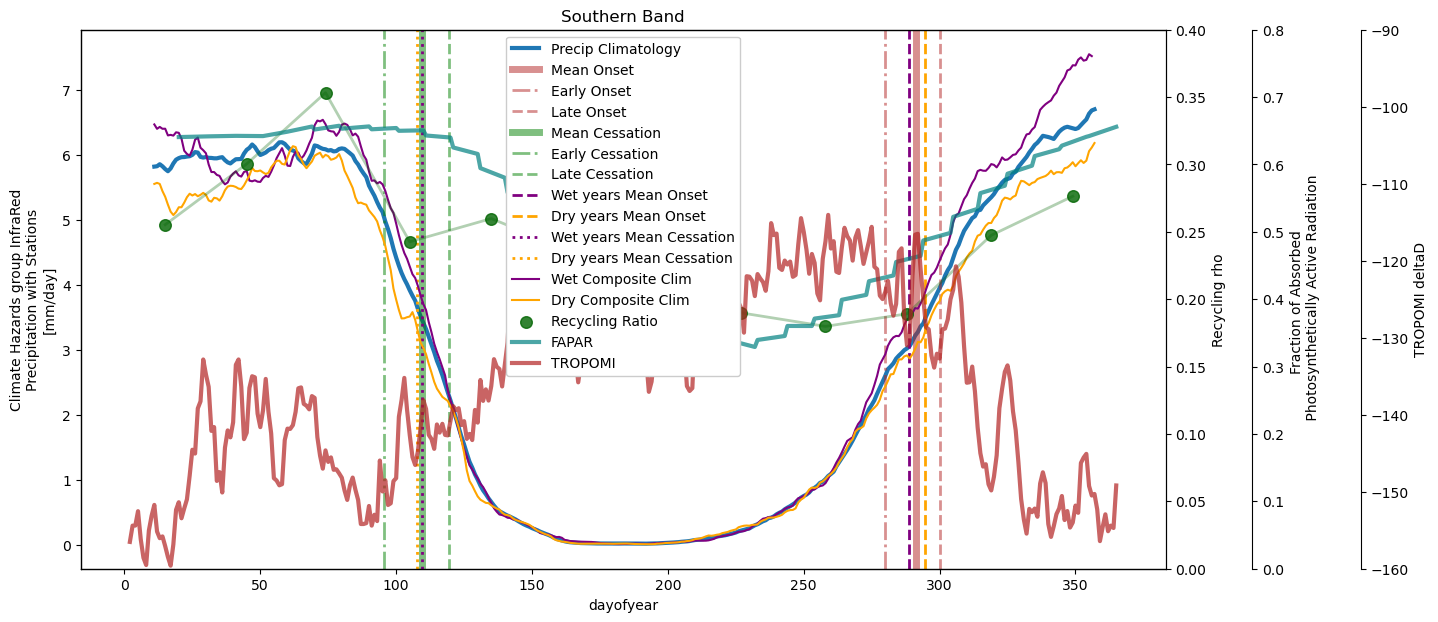

<Figure size 640x480 with 0 Axes>

In [17]:
#Plot everything - SEASON 1

fig,ax = plt.subplots(figsize=(14, 7))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

plt.axvline(x=on1_years.mean('year').values, color='firebrick', linestyle='-', linewidth=5,alpha=0.5,label='Mean Onset')
plt.axvline(x=early_onset1.mean('year'), color='firebrick', linestyle='-.', linewidth=2,alpha=0.5,label='Early Onset')
plt.axvline(x=late_onset1.mean('year'), color='firebrick', linestyle='--', linewidth=2,alpha=0.5,label='Late Onset')

plt.axvline(x=ce1_years.mean('year').values, color='green', linestyle='-', linewidth=5,alpha=0.5,label='Mean Cessation')
plt.axvline(x=early_cess1.mean('year'), color='green', linestyle='-.', linewidth=2,alpha=0.5,label='Early Cessation')
plt.axvline(x=late_cess1.mean('year'), color='green', linestyle='--', linewidth=2,alpha=0.5,label='Late Cessation')

plt.axvline(x=on1_years.sel(year=on1_years['year'].isin(wetS1['year'].values)).mean('year').values, color='purple', linestyle='--', linewidth=2,alpha=1,label='Wet years Mean Onset')
plt.axvline(x=on1_years.sel(year=on1_years['year'].isin(dryS1['year'].values)).mean('year').values, color='orange', linestyle='--', linewidth=2,alpha=1,label='Dry years Mean Onset')
plt.axvline(x=ce1_years.sel(year=ce1_years['year'].isin(wetS1['year'].values)).mean('year').values, color='purple', linestyle='dotted', linewidth=2,alpha=1,label='Wet years Mean Cessation')
plt.axvline(x=ce1_years.sel(year=ce1_years['year'].isin(dryS1['year'].values)).mean('year').values, color='orange', linestyle='dotted', linewidth=2,alpha=1,label='Dry years Mean Cessation')

PonE = P.mean(dim=('lat','lon')).sel(time=P['time.year'].isin(early_onset1['year'].values)).groupby('time.dayofyear').mean('time').rolling(dayofyear=30, center=True).mean('dayofyear')
PonL = P.mean(dim=('lat','lon')).sel(time=P['time.year'].isin(late_onset1['year'].values)).groupby('time.dayofyear').mean('time').rolling(dayofyear=30, center=True).mean('dayofyear')

PceE = P.mean(dim=('lat','lon')).sel(time=P['time.year'].isin(early_cess1['year'].values)).groupby('time.dayofyear').mean('time').rolling(dayofyear=30, center=True).mean('dayofyear')
PceL = P.mean(dim=('lat','lon')).sel(time=P['time.year'].isin(late_cess1['year'].values)).groupby('time.dayofyear').mean('time').rolling(dayofyear=30, center=True).mean('dayofyear')

#plt.fill_between(PonE[0:365].dayofyear,PonE[0:365],PonL[0:365], color='red',alpha=0.3,label="Early vs Late Onset")
#plt.fill_between(PceL[0:365].dayofyear,PceE[0:365],PceL[0:365],color='green',alpha=0.3,label="Early vs Late Cess")
#PonE.plot(linestyle='--',color='red',alpha=1,label="Early Onset Clim")
#PceL.plot(linestyle='--',color='green',alpha=1,label="Late Cessation Clim")

PW1R = PW1.rolling(dayofyear=20, center=True).mean('dayofyear')
PD1R = PD1.rolling(dayofyear=20, center=True).mean('dayofyear')
PW1R.plot(linestyle='-',color='purple',alpha=1,label="Wet Composite Clim")
PD1R.plot(linestyle='-',color='orange',alpha=1,label="Dry Composite Clim")

ax2 = ax.twinx()
ax3 = ax.twinx()
ax4 = ax.twinx()
ax3.spines.right.set_position(("axes", 1.08))
ax4.spines.right.set_position(("axes", 1.18))

ax2.plot(rho_mon['S']['dayofyear'],rho_mon['S'],linestyle='-',linewidth=2,color='darkgreen',alpha=0.3)
ax2.scatter(rho_mon['S']['dayofyear'],rho_mon['S'],s=70,color='darkgreen',label='Recycling Ratio',alpha=0.8)
ax2.set(ylim=(0,0.4),ylabel='Recycling rho')

FPR = FP.rolling(dayofyear=3, center=True).mean('dayofyear')
ax3.plot(FPR['dayofyear'],FPR,linestyle='-',linewidth=3,color='teal',alpha=0.7,label='FAPAR')
ax3.set(ylim=(0.0,0.8),ylabel='Fraction of Absorbed \n Photosynthetically Active Radiation')

TPR = TP.rolling(dayofyear=3, center=True).mean('dayofyear')
ax4.plot(TPR['dayofyear'],TPR,linestyle='-',linewidth=3,color='firebrick',alpha=0.7,label='TROPOMI')
ax4.set(ylim=(-160,-90),ylabel='TROPOMI deltaD')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2 + lines3 + lines4, labels + labels2 + labels3 + labels4, framealpha=1.0, loc='upper center')

plt.title('Southern Band')
plt.savefig(datap+'S_S1_timing_pres.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()